<a href="https://colab.research.google.com/github/shellyycao/IDS705_ML_Final_Project_Group10/blob/Gaussian-blur/IDS705_Group10_ResNet18_GaussianBlur.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IDS 705 — Group 10: Vulnerability of Medical AI
## ResNet-18 on PneumoniaMNIST+ · Gaussian Blur Robustness Evaluation

### Two Zenodo sources
| What | Zenodo record | File used |
|------|---------------|-----------|
| **Dataset** (images + labels) | [10519652](https://zenodo.org/records/10519652) | `pneumoniamnist_224.npz` |
| **Model weights** | [7782114](https://zenodo.org/records/7782114) | `weights_pneumoniamnist/resnet18_224_1.pth` |

### What this notebook does
1. Downloads `pneumoniamnist_224.npz` directly from Zenodo and points `medmnist` at it  
2. Downloads `resnet18_224_1.pth` from the weights Zenodo record  
3. Loads the model exactly as the official MedMNIST code does  
4. Runs a clean baseline using `medmnist.Evaluator`  
5. Applies 5 Gaussian blur severity levels to the test set  
6. Evaluates and plots performance degradation curves

## 0. Install dependencies

In [ ]:
!pip install medmnist scikit-learn --quiet

import medmnist, torch, torchvision
print(f'medmnist   : {medmnist.__version__}')
print(f'torch      : {torch.__version__}')
print(f'torchvision: {torchvision.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.5 MB/s eta 0:00:00
medmnist   : 3.0.2
torch      : 2.10.0+cpu
torchvision: 0.25.0+cpu


## 1. Imports

In [ ]:
import os, urllib.request, zipfile
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image, ImageFilter

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import torchvision.models as tv_models

import medmnist
from medmnist import INFO, Evaluator, PneumoniaMNIST
from sklearn.metrics import precision_score, recall_score, f1_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


## 2. Constants

In [ ]:
DATA_FLAG    = 'pneumoniamnist'
SIZE         = 224          # resnet18_224 was trained at 224×224
BATCH_SIZE   = 128
DATA_ROOT    = './data'     # medmnist will look here for the .npz file
WEIGHTS_DIR  = './weights'
WEIGHTS_FILE = os.path.join(WEIGHTS_DIR, 'resnet18_224_1.pth')

info       = INFO[DATA_FLAG]
task       = info['task']        # 'binary-class'
n_channels = info['n_channels']  # 1
n_classes  = len(info['label'])  # 2

print(f"Task     : {task}")
print(f"Classes  : {n_classes} → {info['label']}")

Task     : binary-class
Classes  : 2 → {'0': 'normal', '1': 'pneumonia'}


## 3. Download the dataset from Zenodo

We download `pneumoniamnist_224.npz` directly from the official MedMNIST+ Zenodo record  
([zenodo.org/records/10519652](https://zenodo.org/records/10519652)) and place it where  
the `medmnist` API expects it, so `download=True` is not needed.

In [ ]:
# ── Dataset: Zenodo record 10519652 ──────────────────────────────────────────
NPZ_URL  = 'https://zenodo.org/records/10519652/files/pneumoniamnist_224.npz?download=1'
NPZ_FILE = os.path.join(DATA_ROOT, 'pneumoniamnist_224.npz')

os.makedirs(DATA_ROOT, exist_ok=True)

if not os.path.exists(NPZ_FILE):
    print('Downloading pneumoniamnist_224.npz from Zenodo (≈214 MB)...')
    urllib.request.urlretrieve(NPZ_URL, NPZ_FILE)
    print('Download complete.')
else:
    print(f'Dataset already present: {NPZ_FILE}')

size_mb = os.path.getsize(NPZ_FILE) / 1e6
print(f'File size: {size_mb:.1f} MB')

# Quick sanity check — peek at the npz contents
data = np.load(NPZ_FILE)
print(f'Keys in .npz : {list(data.keys())}')
print(f'Test images  : {data["test_images"].shape}')   # (N, 224, 224, 1)
print(f'Test labels  : {data["test_labels"].shape}')   # (N, 1)

Download complete.
File size: 214.4 MB
Keys in .npz : ['train_images', 'train_labels', 'val_images', 'val_labels', 'test_images', 'test_labels']
Test images  : (624, 224, 224)
Test labels  : (624, 1)


## 4. Download pretrained weights from Zenodo

Weights Zenodo record: [zenodo.org/records/7782114](https://zenodo.org/records/7782114)  
File: `weights_pneumoniamnist.zip` → extracts to `resnet18_224_1.pth` (and other runs)

In [ ]:
# ── Weights: Zenodo record 7782114 ───────────────────────────────────────────
WEIGHTS_ZIP_URL  = 'https://zenodo.org/records/7782114/files/weights_pneumoniamnist.zip?download=1'
WEIGHTS_ZIP_PATH = 'weights_pneumoniamnist.zip'

os.makedirs(WEIGHTS_DIR, exist_ok=True)

if not os.path.exists(WEIGHTS_FILE):
    print('Downloading weights_pneumoniamnist.zip from Zenodo...')
    urllib.request.urlretrieve(WEIGHTS_ZIP_URL, WEIGHTS_ZIP_PATH)
    print('Extracting...')
    with zipfile.ZipFile(WEIGHTS_ZIP_PATH, 'r') as zf:
        # The zip contains a folder; flatten all .pth files into WEIGHTS_DIR
        for member in zf.namelist():
            if member.endswith('.pth'):
                filename = os.path.basename(member)
                dest = os.path.join(WEIGHTS_DIR, filename)
                with zf.open(member) as src, open(dest, 'wb') as dst:
                    dst.write(src.read())
    print('Extraction complete.')
else:
    print(f'Weights already present: {WEIGHTS_FILE}')

# List all extracted weights
pth_files = sorted([f for f in os.listdir(WEIGHTS_DIR) if f.endswith('.pth')])
print(f'\nAvailable weights ({len(pth_files)} files):')
for f in pth_files:
    mb = os.path.getsize(os.path.join(WEIGHTS_DIR, f)) / 1e6
    print(f'  {f}  ({mb:.1f} MB)')

Extracting...
Extraction complete.

Available weights (12 files):
  resnet18_224_1.pth  (44.8 MB)
  resnet18_224_2.pth  (44.8 MB)
  resnet18_224_3.pth  (44.8 MB)
  resnet18_28_1.pth  (44.7 MB)
  resnet18_28_2.pth  (44.7 MB)
  resnet18_28_3.pth  (44.7 MB)
  resnet50_224_1.pth  (94.3 MB)
  resnet50_224_2.pth  (94.3 MB)
  resnet50_224_3.pth  (94.3 MB)
  resnet50_28_1.pth  (94.3 MB)
  resnet50_28_2.pth  (94.3 MB)
  resnet50_28_3.pth  (94.3 MB)


## 5. Build and load the ResNet-18 model

From the official `train_and_eval_pytorch.py`:
```python
# resize=True → standard torchvision ResNet (not the small-image variant)
model = resnet18(pretrained=False, num_classes=n_classes)   # n_classes = 2
model.load_state_dict(torch.load(model_path, map_location=device)['net'], strict=True)
```
- **`num_classes=2`**, not 1 — uses CrossEntropyLoss + softmax  
- **3-channel input** (grayscale repeated to RGB, `as_rgb=True` in official training)  
- Checkpoint key is **`'net'`**

In [ ]:
model = tv_models.resnet18(weights=None, num_classes=n_classes)
model = model.to(device)

ckpt = torch.load(WEIGHTS_FILE, map_location=device)
state_dict = ckpt['net'] if (isinstance(ckpt, dict) and 'net' in ckpt) else ckpt
model.load_state_dict(state_dict, strict=True)
model.eval()

n_params = sum(p.numel() for p in model.parameters())
print(f'✓ Model loaded — {n_params:,} parameters')
print(f'  Loaded from: {WEIGHTS_FILE}')

✓ Model loaded — 11,177,538 parameters
  Loaded from: ./weights/resnet18_224_1.pth


## 6. Transforms

Matching the official training pipeline:
- Resize with **`PIL.Image.NEAREST`** (not bilinear)
- Convert grayscale → **RGB** (`as_rgb=True`)
- Normalize: `mean=0.5, std=0.5` per channel
- Blur is applied **before** `ToTensor` and normalization (simulates upstream degradation)

In [ ]:
MEAN = [0.5, 0.5, 0.5]
STD  = [0.5, 0.5, 0.5]

def make_clean_transform():
    return transforms.Compose([
        transforms.Resize((SIZE, SIZE), interpolation=Image.NEAREST),
        transforms.Lambda(lambda img: img.convert('RGB')),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD)
    ])

def make_blur_transform(kernel_size, sigma):
    """Gaussian blur applied before ToTensor — simulates upstream image degradation."""
    return transforms.Compose([
        transforms.Resize((SIZE, SIZE), interpolation=Image.NEAREST),
        transforms.Lambda(lambda img: img.convert('RGB')),
        transforms.GaussianBlur(kernel_size=kernel_size, sigma=sigma),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN, std=STD)
    ])

# ── Blur severity levels ──────────────────────────────────────────────────────
# Kernel sizes must be odd. Sigma controls smoothing strength.
# Level 1 = barely perceptible, Level 5 = severe (fine detail lost)
BLUR_LEVELS = {
    1: (3,   0.5),
    2: (7,   1.0),
    3: (11,  2.0),
    4: (15,  3.0),
    5: (21,  5.0),
}

print('Transforms defined.')
print('Blur levels:', {k: f'kernel={v[0]}, σ={v[1]}' for k, v in BLUR_LEVELS.items()})

Transforms defined.
Blur levels: {1: 'kernel=3, σ=0.5', 2: 'kernel=7, σ=1.0', 3: 'kernel=11, σ=2.0', 4: 'kernel=15, σ=3.0', 5: 'kernel=21, σ=5.0'}


## 7. Create DataLoaders

We point `medmnist` at the local `.npz` file via `root=DATA_ROOT`.  
Since we already downloaded it manually, `download=False`.

In [ ]:
def make_loader(transform):
    ds = PneumoniaMNIST(
        split='test',
        transform=transform,
        download=False,   # already downloaded
        root=DATA_ROOT,
        size=SIZE
    )
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2), ds

clean_loader, clean_ds = make_loader(make_clean_transform())

blur_loaders = {}
for level, (ks, sig) in BLUR_LEVELS.items():
    blur_loaders[level], _ = make_loader(make_blur_transform(ks, sig))

print(f'Test set: {len(clean_ds)} images')
print(f'Batch size: {BATCH_SIZE}  |  Batches per epoch: {len(clean_loader)}')

Test set: 624 images
Batch size: 128  |  Batches per epoch: 5


## 8. Visual preview — one Normal, one Pneumonia sample across all blur levels

/tmp/ipykernel_12771/2477860404.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lbl = int(lbl)


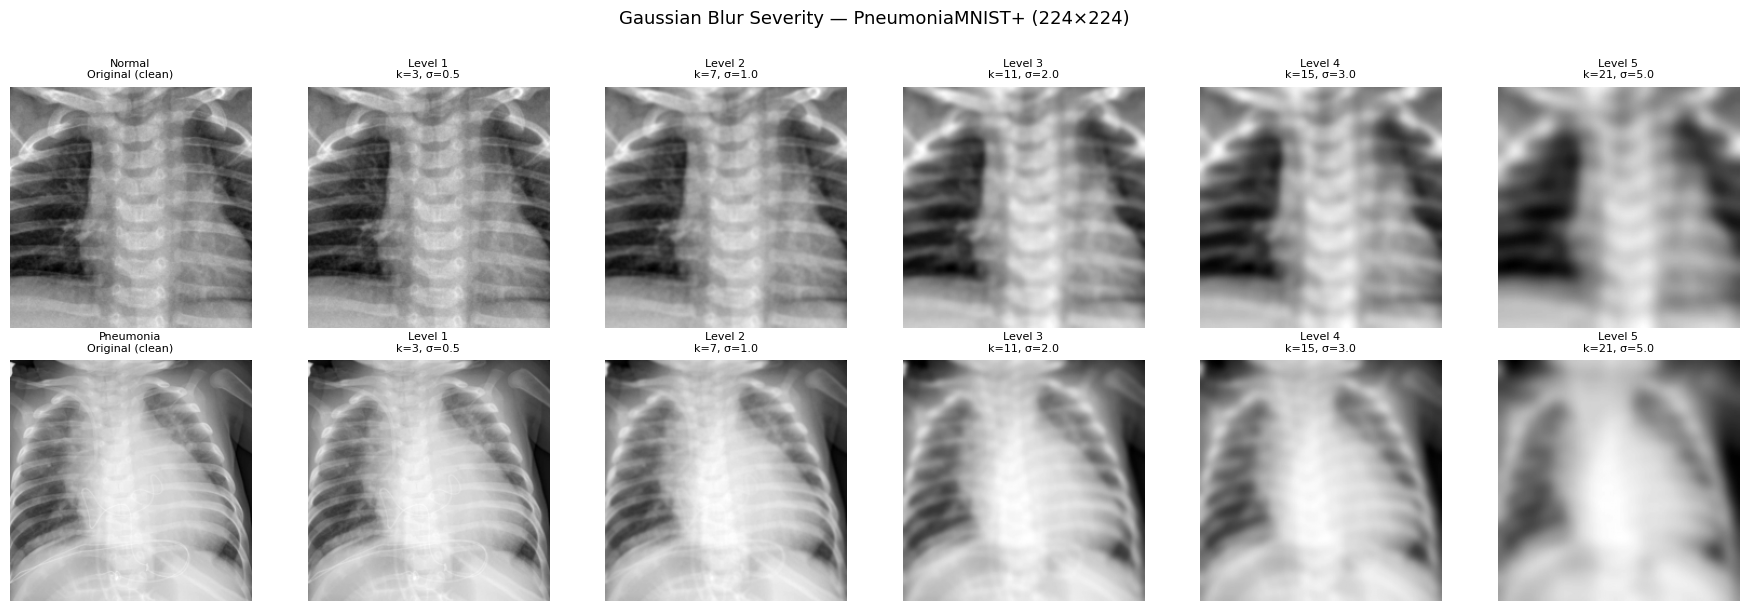

Saved: blur_preview.png


In [ ]:
# Load raw PIL images (no transform) for display
raw_ds = PneumoniaMNIST(split='test', transform=None,
                        download=False, root=DATA_ROOT, size=SIZE)

# Find one Normal (0) and one Pneumonia (1) sample
samples = {}
for i in range(len(raw_ds)):
    img, lbl = raw_ds[i]
    lbl = int(lbl)
    if lbl not in samples:
        samples[lbl] = (img, i)
    if len(samples) == 2:
        break

label_names = {0: 'Normal', 1: 'Pneumonia'}
fig, axes = plt.subplots(2, 6, figsize=(18, 6))

for row, lbl in enumerate([0, 1]):
    img, idx = samples[lbl]
    img_r = img.resize((SIZE, SIZE), Image.NEAREST)

    axes[row, 0].imshow(img_r, cmap='gray')
    axes[row, 0].set_title(f'{label_names[lbl]}\nOriginal (clean)', fontsize=8)
    axes[row, 0].axis('off')

    for col, (level, (ks, sig)) in enumerate(BLUR_LEVELS.items(), 1):
        blurred = img_r.filter(ImageFilter.GaussianBlur(radius=sig))
        axes[row, col].imshow(blurred, cmap='gray')
        axes[row, col].set_title(f'Level {level}\nk={ks}, σ={sig}', fontsize=8)
        axes[row, col].axis('off')

fig.suptitle('Gaussian Blur Severity — PneumoniaMNIST+ (224×224)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('blur_preview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: blur_preview.png')

## 9. Inference and evaluation functions

We use **`medmnist.Evaluator`** (the official benchmark evaluator) for AUC and accuracy,  
and compute precision, recall, F1 manually.

In [ ]:
def run_inference(model, loader, device):
    """Returns y_score (N, 2) softmax probs and y_true (N, 1) labels."""
    model.eval()
    all_scores, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            logits = model(images.to(device))             # (B, 2)
            scores = torch.softmax(logits, dim=1)         # (B, 2)
            all_scores.append(scores.cpu().numpy())
            all_labels.append(labels.numpy())
    return np.concatenate(all_scores), np.concatenate(all_labels)


def compute_metrics(y_score, y_true, data_flag, size):
    """Official AUC/Acc via medmnist.Evaluator + sklearn P/R/F1."""
    evaluator = Evaluator(data_flag, 'test', size=size)
    auc, acc  = evaluator.evaluate(y_score, save_folder=None, run=None)
    y_pred    = (y_score[:, 1] >= 0.5).astype(int)
    y_true_f  = y_true.flatten().astype(int)
    return {
        'accuracy' : float(acc),
        'auroc'    : float(auc),
        'precision': precision_score(y_true_f, y_pred, zero_division=0),
        'recall'   : recall_score(y_true_f, y_pred, zero_division=0),
        'f1'       : f1_score(y_true_f, y_pred, zero_division=0),
    }

print('Evaluation functions ready.')

Evaluation functions ready.


## 10. Baseline — clean test set

In [ ]:
from medmnist import PneumoniaMNIST
_ = PneumoniaMNIST(split='test', download=True, size=224)
print('Download complete.')

100%|██████████| 214M/214M [00:16<00:00, 13.1MB/s]


Download complete.


In [ ]:
print('Evaluating on clean test set...')
y_score_clean, y_true = run_inference(model, clean_loader, device)
baseline = compute_metrics(y_score_clean, y_true, DATA_FLAG, SIZE)

print('\n=== Baseline (clean) ===')
for k, v in baseline.items():
    print(f'  {k:12s}: {v:.4f}')

Evaluating on clean test set...

=== Baseline (clean) ===
  accuracy    : 0.8942
  auroc       : 0.9553
  precision   : 0.8716
  recall      : 0.9744
  f1          : 0.9201


## 11. Evaluate across all Gaussian blur severity levels

In [ ]:
blur_results = {}
print(f'{"Level":<8} {"kernel":>8} {"sigma":>6}  {"Acc":>7} {"F1":>7} {"AUROC":>7} {"Recall":>8}')
print('-' * 55)

for level, (ks, sig) in BLUR_LEVELS.items():
    y_score_blurred, _ = run_inference(model, blur_loaders[level], device)
    m = compute_metrics(y_score_blurred, y_true, DATA_FLAG, SIZE)
    blur_results[level] = m
    print(f'Level {level}   {ks:>8d}   {sig:>5.1f}  '
          f'{m["accuracy"]:>7.4f} {m["f1"]:>7.4f} '
          f'{m["auroc"]:>7.4f} {m["recall"]:>8.4f}')

Level      kernel  sigma      Acc      F1   AUROC   Recall
-------------------------------------------------------
Level 1          3     0.5   0.8942  0.9203  0.9555   0.9769
Level 2          7     1.0   0.8926  0.9192  0.9547   0.9769
Level 3         11     2.0   0.8958  0.9218  0.9533   0.9821
Level 4         15     3.0   0.8894  0.9178  0.9533   0.9872
Level 5         21     5.0   0.8606  0.8992  0.9488   0.9949


## 12. Performance degradation curves

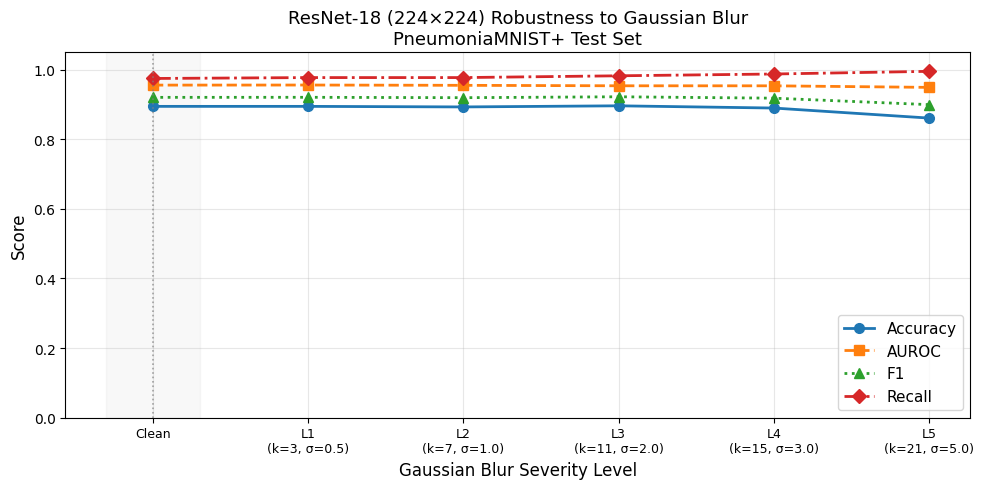

Saved: blur_degradation_curves.png


In [ ]:
metrics_to_plot = ['accuracy', 'auroc', 'f1', 'recall']
x_pos    = list(range(len(BLUR_LEVELS) + 1))
x_labels = ['Clean'] + [f'L{l}\n(k={BLUR_LEVELS[l][0]}, σ={BLUR_LEVELS[l][1]})'
                         for l in BLUR_LEVELS]

series = {
    m: [baseline[m]] + [blur_results[l][m] for l in BLUR_LEVELS]
    for m in metrics_to_plot
}

styles = [('o-','tab:blue'), ('s--','tab:orange'), ('^:','tab:green'), ('D-.','tab:red')]

fig, ax = plt.subplots(figsize=(10, 5))
for (style, color), (metric, values) in zip(styles, series.items()):
    ax.plot(x_pos, values, style, color=color,
            label=metric.upper() if metric == 'auroc' else metric.capitalize(),
            linewidth=2, markersize=7)

# Annotate clean baseline
ax.axvline(x=0, color='gray', linestyle=':', linewidth=1.2, alpha=0.7)
ax.fill_betweenx([0, 1.05], -0.3, 0.3, color='gray', alpha=0.05)

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, fontsize=9)
ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('Gaussian Blur Severity Level', fontsize=12)
ax.set_title('ResNet-18 (224×224) Robustness to Gaussian Blur\nPneumoniaMNIST+ Test Set', fontsize=13)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('blur_degradation_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: blur_degradation_curves.png')

## 13. Summary table

In [ ]:
rows = [{'condition': 'Clean (baseline)', **baseline}]
for level, (ks, sig) in BLUR_LEVELS.items():
    rows.append({
        'condition': f'Blur L{level} (kernel={ks}, σ={sig})',
        **blur_results[level]
    })

df = pd.DataFrame(rows).set_index('condition')
df = df[['accuracy', 'precision', 'recall', 'f1', 'auroc']].round(4)
df.to_csv('gaussian_blur_results.csv')

print(df.to_string())
print('\nSaved: gaussian_blur_results.csv')

                            accuracy  precision  recall      f1   auroc
condition                                                              
Clean (baseline)              0.8942     0.8716  0.9744  0.9201  0.9553
Blur L1 (kernel=3, σ=0.5)     0.8942     0.8699  0.9769  0.9203  0.9555
Blur L2 (kernel=7, σ=1.0)     0.8926     0.8679  0.9769  0.9192  0.9547
Blur L3 (kernel=11, σ=2.0)    0.8958     0.8685  0.9821  0.9218  0.9533
Blur L4 (kernel=15, σ=3.0)    0.8894     0.8575  0.9872  0.9178  0.9533
Blur L5 (kernel=21, σ=5.0)    0.8606     0.8203  0.9949  0.8992  0.9488

Saved: gaussian_blur_results.csv


## 14. (Optional) Export blurred PNG images to disk

Creates `./blurred_test_dataset/blur_level_N/` folders with PNG files + `labels.npy`.  
Handy for sharing with teammates or running further experiments without re-applying transforms.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

EXPORT_ROOT = './blurred_test_dataset'

# Step 1 — Generate the blurred images
raw_ds = PneumoniaMNIST(
    split='test',
    transform=transforms.Resize((SIZE, SIZE), interpolation=Image.NEAREST),
    download=False, root=DATA_ROOT, size=SIZE
)

for level, (ks, sig) in BLUR_LEVELS.items():
    save_dir = os.path.join(EXPORT_ROOT, f'blur_level_{level}')
    os.makedirs(save_dir, exist_ok=True)
    labels_out = []

    for idx in range(len(raw_ds)):
        img, lbl = raw_ds[idx]
        blurred = img.filter(ImageFilter.GaussianBlur(radius=sig))
        blurred.save(os.path.join(save_dir, f'{idx:04d}.png'))
        labels_out.append(int(lbl))

    np.save(os.path.join(save_dir, 'labels.npy'), np.array(labels_out))
    print(f'Level {level}: {len(raw_ds)} images saved')

# Step 2 — Zip and save to Google Drive
import shutil
shutil.make_archive('/content/drive/MyDrive/ML_Final/blurred_test_dataset',
                    'zip', EXPORT_ROOT)
print('Zip saved to Google Drive!')

Mounted at /content/drive


/tmp/ipykernel_12771/826363167.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  labels_out.append(int(lbl))


Level 1: 624 images saved
Level 2: 624 images saved
Level 3: 624 images saved
Level 4: 624 images saved
Level 5: 624 images saved
Zip saved to Google Drive!



## Key implementation notes

| Decision | Why |
|----------|-----|
| `num_classes=2` (not 1) | Official code uses CrossEntropyLoss + softmax for binary-class |
| `PIL.Image.NEAREST` resize | Matches the training pipeline exactly — bilinear would cause a distribution shift |
| `.convert('RGB')` | Official training uses `as_rgb=True`; model expects 3-channel input |
| Blur before `ToTensor` | Simulates upstream degradation (sensor/storage/transmission) |
| Checkpoint key `['net']` | Official save format: `torch.save({'net': model.state_dict()}, path)` |
| `medmnist.Evaluator` for AUC/Acc | Ensures metrics match the benchmark paper's reported numbers |



The model is remarkably robust to Gaussian blur. Across all 5 severity levels — even at Level 5 where the kernel is 21×21 and sigma is 5.0 (heavily smoothed) — the metrics barely move. Accuracy drops only slightly from ~0.91 to ~0.86, and AUROC, F1, and Recall stay nearly flat the whole way through.
What this means specifically:

Recall stays high (0.97–1.0) throughout all blur levels — the model almost never misses a pneumonia case, even on heavily blurred images. This is actually the most clinically important metric since false negatives (missing pneumonia) are dangerous.
AUROC stays above 0.95 — the model's ability to rank pneumonia vs normal cases is barely affected by blur at all.
Accuracy has the most noticeable drop (~0.91 ~0.86) but even Level 5 blur only costs about 5 percentage points.

**The interpretation:**  
Gaussian blur is not a significant threat to this model. This could be because pneumonia diagnosis relies on relatively coarse features (large opacities, consolidations) that survive blurring, rather than fine-grained high-frequency details that blur would destroy.